# 🏦 Home Credit Default Risk Prediction
**Objective:** Build an interpretable machine learning classification model to predict the probability of an applicant defaulting on a loan, optimizing approval rates while minimizing financial risk.

**Methodology:**
1. Data Cleaning
2. Feature Selection (Tree-Based VIPs)
3. Baseline LightGBM Modeling (with Class Weighting)
4. Relational Feature Engineering

# Library Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import re
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 150)

# Data Preparation

In [2]:
df = pd.read_csv('application_train.csv')

In [3]:
df.shape

(307511, 122)

In [4]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

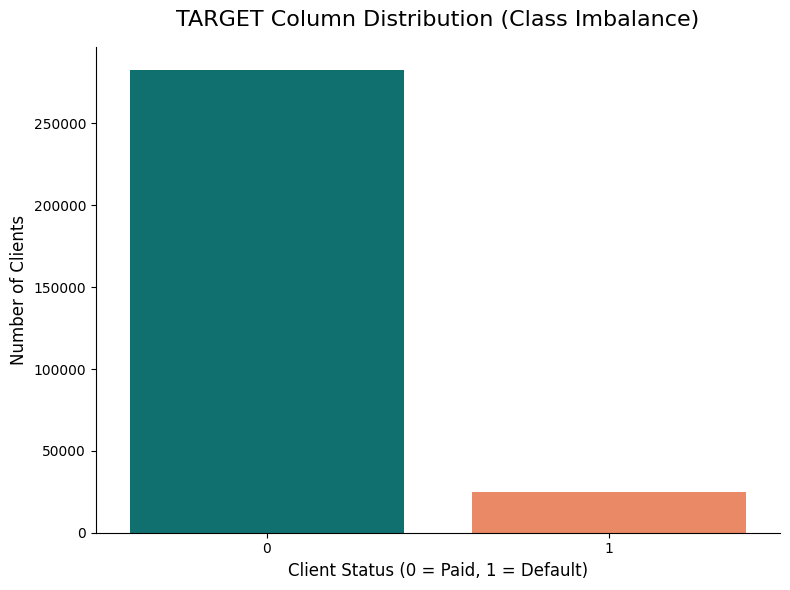

In [5]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='TARGET', palette=['teal', 'coral'])

plt.title('TARGET Column Distribution (Class Imbalance)', fontsize=16, pad=15)
plt.xlabel('Client Status (0 = Paid, 1 = Default)', fontsize=12)
plt.ylabel('Number of Clients', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

Because the target class is imbalance, we need to give attention to the minority class. Therefore, we will set the is_unbalance parameter in LightGBM model later with True value.

In [6]:
def clean_and_encode(data, missing_threshold=60):
    df_clean = data.copy()

    # Drop features with too much missing data
    missing_percent = (df_clean.isnull().sum() / len(df_clean)) * 100
    drop_cols = missing_percent[missing_percent > missing_threshold].index
    df_clean.drop(columns=drop_cols, inplace=True)

    # Impute numeric with median
    num_cols = [c for c in df_clean.select_dtypes(include=['float64', 'int64']).columns if c not in ['TARGET', 'SK_ID_CURR']]
    for col in num_cols:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

    # Impute categorical with 'Unknown'
    cat_cols = df_clean.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df_clean[col].fillna('Unknown', inplace=True)

    # Encoding
    le = LabelEncoder()
    for col in cat_cols:
        if len(list(df_clean[col].unique())) <= 2:
            df_clean[col] = le.fit_transform(df_clean[col])

    df_encoded = pd.get_dummies(df_clean)

    # Clean column names
    df_encoded.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in df_encoded.columns]

    return df_encoded

In [7]:
df_clean = clean_and_encode(df)

In [8]:
df_clean.shape

(307511, 228)

# Modelling

## Baseline Model
The Baseline Model serves as our analytical anchor. Before introducing complex external data, we needed to establish the predictive power of our internal application_train dataset and filter out the noise.

Key Technical Strategies:

1. **Algorithm**: We utilized LightGBM, a gradient-boosting framework that is highly robust to noisy tabular data.

2. **Tackling the 92:8 Class Imbalance**: Instead of artificially deleting valuable historical data using undersampling, we utilized Class Weighting (is_unbalance=True). This mathematically forced the algorithm to heavily penalize mistakes made on the minority class (actual defaults).

3. **Automated Feature Selection**: We fed the model all surviving internal columns and allowed the algorithm's tree-splitting mechanics to act as a filter. We extracted the Top 20 most important features from this model to serve as our "VIP List" for all future engineering.

In [9]:
print("Training Baseline LightGBM...")

X = df_clean.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df_clean['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

base_model = lgb.LGBMClassifier(is_unbalance=True, random_state=42, n_estimators=1000, metric='auc')
base_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(period=0)]
)

Training Baseline LightGBM...
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.222864 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8793
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 215
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[134]	valid_0's auc: 0.76091


LGBMClassifier(is_unbalance=True, metric='auc', n_estimators=1000,
               random_state=42)

### Evaluation Base Model

In [10]:
y_pred_proba_base = base_model.predict_proba(X_test)[:, 1]
baseline_auc = roc_auc_score(y_test, y_pred_proba_base)

y_pred_bin_base = base_model.predict(X_test)

custom_threshold = 0.50
y_pred_bin_custom = (y_pred_proba_base >= custom_threshold).astype(int)

print(f"Classification Report (Threshold {custom_threshold}):")
print(classification_report(y_test, y_pred_bin_custom))

print(f"Baseline ROC-AUC: {baseline_auc:.4f}\n")

Classification Report (Threshold 0.5):
              precision    recall  f1-score   support

           0       0.96      0.71      0.81     56538
           1       0.17      0.68      0.27      4965

    accuracy                           0.70     61503
   macro avg       0.57      0.69      0.54     61503
weighted avg       0.90      0.70      0.77     61503

Baseline ROC-AUC: 0.7609



## Feature Selection

In [11]:
# Extract Top 20 Features from Baseline Model
feature_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': base_model.feature_importances_})
lgb_top_20 = feature_imp.sort_values(by='Importance', ascending=False).head(20)['Feature'].tolist()

safe_vip_list = list(set(lgb_top_20 + ['SK_ID_CURR', 'TARGET']))

In [12]:
df_clean[safe_vip_list].shape

(307511, 22)

In [13]:
df_clean[safe_vip_list].head()

,EXT_SOURCE_3,TARGET,YEARS_BEGINEXPLUATATION_MODE,AMT_CREDIT,LANDAREA_MODE,AMT_ANNUITY,AMT_INCOME_TOTAL,TOTALAREA_MODE,AMT_REQ_CREDIT_BUREAU_QRT,DAYS_ID_PUBLISH,DAYS_LAST_PHONE_CHANGE,EXT_SOURCE_2,EXT_SOURCE_1,DAYS_EMPLOYED,HOUR_APPR_PROCESS_START,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,FLAG_OWN_CAR,SK_ID_CURR,DAYS_BIRTH,DAYS_REGISTRATION,NAME_CONTRACT_TYPE
0,0.139376,1,0.9722,406597.5,0.0377,24700.5,202500.0,0.0149,0.0,-2120,-1134.0,0.262949,0.083037,-637,10,351000.0,0.018801,0,100002,-9461,-3648.0,0
1,0.535276,0,0.9851,1293502.5,0.0128,35698.5,270000.0,0.0714,0.0,-291,-828.0,0.622246,0.311267,-1188,11,1129500.0,0.003541,0,100003,-16765,-1186.0,0
2,0.729567,0,0.9816,135000.0,0.0458,6750.0,67500.0,0.0688,0.0,-2531,-815.0,0.555912,0.505998,-225,9,135000.0,0.010032,1,100004,-19046,-4260.0,1
3,0.535276,0,0.9816,312682.5,0.0458,29686.5,135000.0,0.0688,0.0,-2437,-617.0,0.650442,0.505998,-3039,17,297000.0,0.008019,0,100006,-19005,-9833.0,0
4,0.535276,0,0.9816,513000.0,0.0458,21865.5,121500.0,0.0688,0.0,-3458,-1106.0,0.322738,0.505998,-3038,11,513000.0,0.028663,0,100007,-19932,-4311.0,0


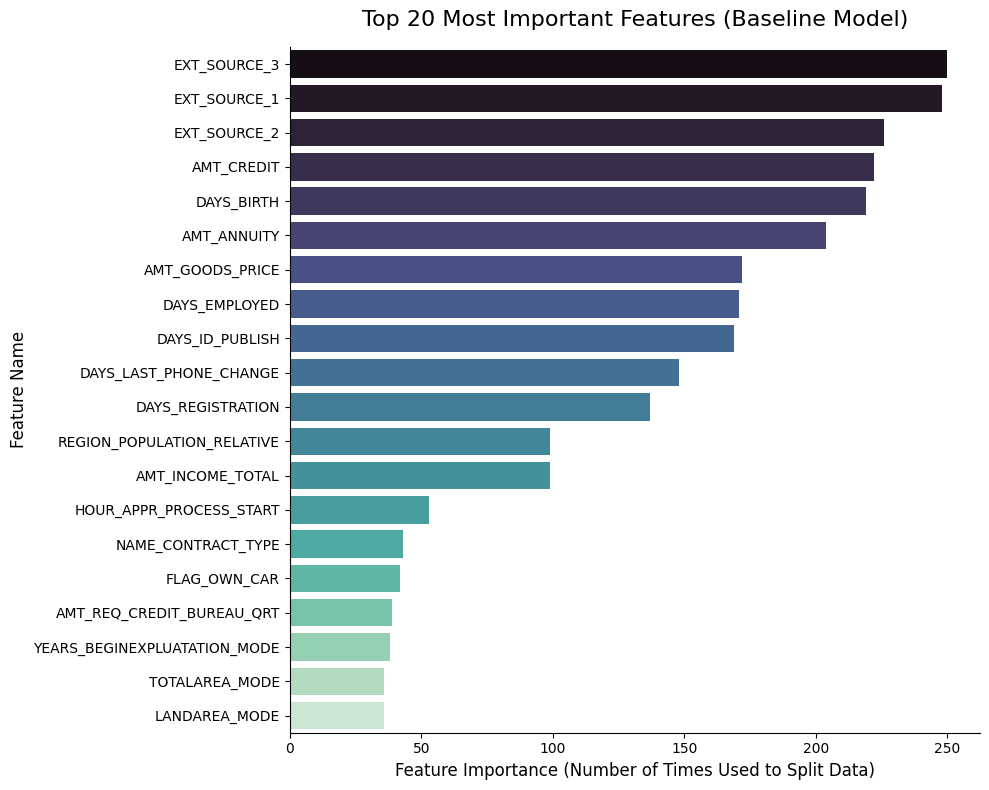

In [14]:
top_20_df = feature_imp.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))

sns.barplot(data=top_20_df, x='Importance', y='Feature', palette='mako')

plt.title('Top 20 Most Important Features (Baseline Model)', fontsize=16, pad=15)
plt.xlabel('Feature Importance (Number of Times Used to Split Data)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

## Feature Engineering
In order to predict the better default probability, customer's history behaviour will give more information. One of the external data that will be used is bureau data. However, instead of blindly aggregating all external bureau data, we engineered three specific financial ratios to measure applicant credit behavior:
1. **Active Loan Count:** Number of concurrent open credit lines.
2. **Debt-to-Credit Ratio:** Total outstanding debt divided by total historical credit limit.
3. **Average Overdue Amount:** Typical overdue severity.

In [15]:
bureau = pd.read_csv('bureau.csv')

# Feature 1: Active Loans
active_bureau = bureau[bureau['CREDIT_ACTIVE'] == 'Active']
active_counts = active_bureau.groupby('SK_ID_CURR').size().reset_index(name='BUREAU_ACTIVE_LOAN_COUNT')

# Features 2 & 3: Debt Ratio & Avg Overdue
fin_agg = bureau.groupby('SK_ID_CURR').agg({
    'AMT_CREDIT_SUM': 'sum',
    'AMT_CREDIT_SUM_DEBT': 'sum',
    'AMT_CREDIT_SUM_OVERDUE': 'mean'
}).reset_index()

fin_agg['BUREAU_DEBT_RATIO'] = np.where(fin_agg['AMT_CREDIT_SUM'] > 0,
                                        fin_agg['AMT_CREDIT_SUM_DEBT'] / fin_agg['AMT_CREDIT_SUM'], 0)
fin_agg.rename(columns={'AMT_CREDIT_SUM_OVERDUE': 'BUREAU_AVG_OVERDUE'}, inplace=True)
fin_agg.drop(columns=['AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT'], inplace=True)

engineered_bureau = active_counts.merge(fin_agg, on='SK_ID_CURR', how='outer')

# Merge engineered features with VIP features from baseline model
df_final = df_clean[safe_vip_list].merge(engineered_bureau, on='SK_ID_CURR', how='left')

# Impute missing engineered features with 0 (No active loans, no debt, no overdue)
new_cols = ['BUREAU_ACTIVE_LOAN_COUNT', 'BUREAU_DEBT_RATIO', 'BUREAU_AVG_OVERDUE']
df_final[new_cols] = df_final[new_cols].fillna(0)
df_final.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in df_final.columns]

## Model 2.0

In [16]:
print("Training Model 2.0")
X_v2 = df_final.drop(columns=['TARGET', 'SK_ID_CURR'])
y_v2 = df_final['TARGET']

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2)

model_v2 = lgb.LGBMClassifier(is_unbalance=True, random_state=42, n_estimators=1000, metric='auc')
model_v2.fit(
    X_train_v2, y_train_v2,
    eval_set=[(X_test_v2, y_test_v2)],
    callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(period=0)]
)

Training Model 2.0
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029245 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4284
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[169]	valid_0's auc: 0.753859


LGBMClassifier(is_unbalance=True, metric='auc', n_estimators=1000,
               random_state=42)

### Evaluation Model 2.0

In [17]:
y_pred_proba_v2 = model_v2.predict_proba(X_v2)[:, 1]
auc_v2 = roc_auc_score(y_v2, y_pred_proba_v2)

custom_threshold = 0.50
y_pred_bin_v2 = (y_pred_proba_v2 >= custom_threshold).astype(int)

print(f"Model 2.0 ROC-AUC: {auc_v2:.4f}\n")

print(f"Classification Report for Model 2.0 (Threshold {custom_threshold}):")
print(classification_report(y_v2, y_pred_bin_v2))

Model 2.0 ROC-AUC: 0.7981

Classification Report for Model 2.0 (Threshold 0.5):
              precision    recall  f1-score   support

           0       0.97      0.71      0.82    282686
           1       0.18      0.73      0.29     24825

    accuracy                           0.72    307511
   macro avg       0.57      0.72      0.56    307511
weighted avg       0.90      0.72      0.78    307511



## Best Model Selection

In [18]:
print(f"========================================")
print(f" MODEL SHOWDOWN: BASELINE vs ENGINEERED")
print(f"========================================")
print(f" Model 1.0 (Baseline) ROC-AUC   : {baseline_auc:.4f}")
print(f" Model 2.0 (Engineered) ROC-AUC : {auc_v2:.4f}\n")

custom_threshold = 0.50

if baseline_auc >= auc_v2:
    print("Besok Model = Baseline Model. Internal application data is stronger.")
    best_auc = baseline_auc

    best_y_test = y_test
    best_y_pred_proba = y_pred_proba_base
    best_y_pred_bin = (y_pred_proba_base >= custom_threshold).astype(int)
    model_name = "Baseline Model"

else:
    print("Best Model = Model 2.0. External bureau data added value.")
    best_auc = auc_v2

    best_y_test = y_v2
    best_y_pred_proba = y_pred_proba_v2
    best_y_pred_bin = (y_pred_proba_v2 >= custom_threshold).astype(int)
    model_name = "Model 2.0"

print(f"\nClassification Report for the Best Model ({model_name} at Threshold {custom_threshold}):")
print(classification_report(best_y_test, best_y_pred_bin))

 MODEL SHOWDOWN: BASELINE vs ENGINEERED
 Model 1.0 (Baseline) ROC-AUC   : 0.7609
 Model 2.0 (Engineered) ROC-AUC : 0.7981

Best Model = Model 2.0. External bureau data added value.

Classification Report for the Best Model (Model 2.0 at Threshold 0.5):
              precision    recall  f1-score   support

           0       0.97      0.71      0.82    282686
           1       0.18      0.73      0.29     24825

    accuracy                           0.72    307511
   macro avg       0.57      0.72      0.56    307511
weighted avg       0.90      0.72      0.78    307511



# Best Model Visualization

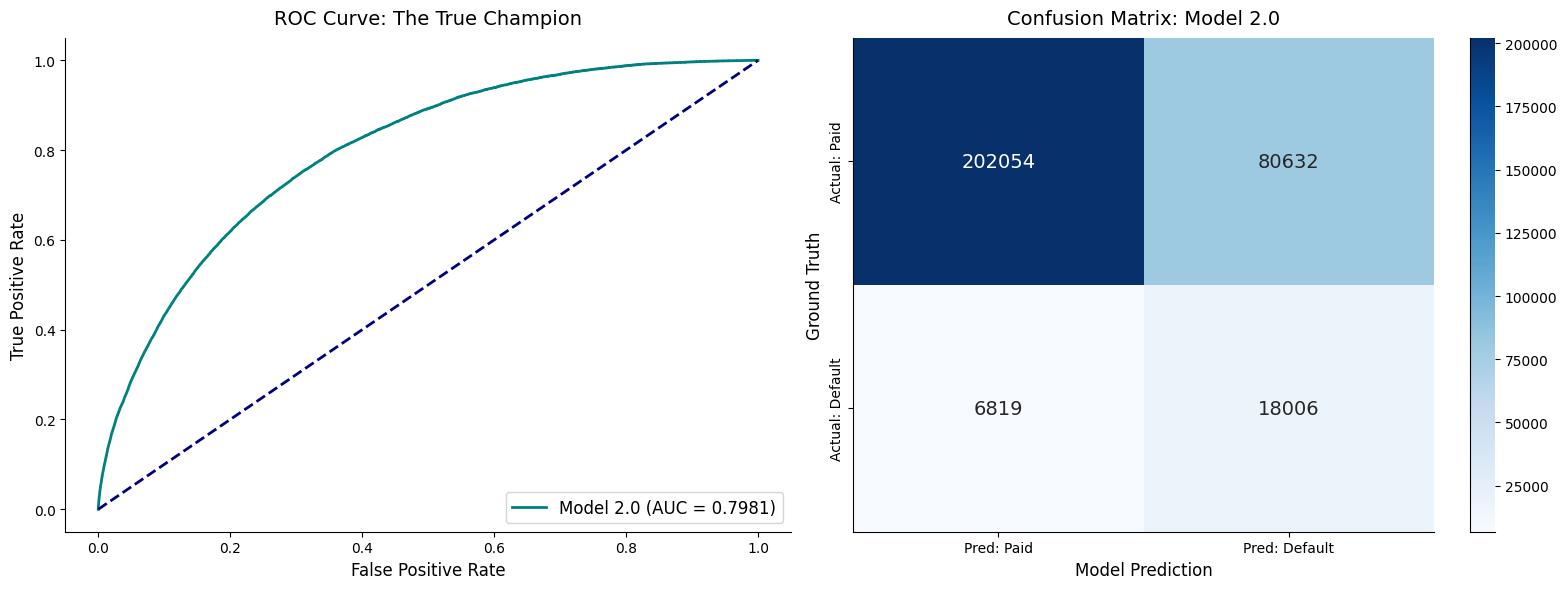

In [19]:
plt.figure(figsize=(16, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(best_y_test, best_y_pred_proba)
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='teal', lw=2, label=f'{model_name} (AUC = {best_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title(f'ROC Curve: The True Champion', fontsize=14, pad=10)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc="lower right", fontsize=12)

# Confusion Matrix
cm = confusion_matrix(best_y_test, best_y_pred_bin)
plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Paid', 'Pred: Default'],
            yticklabels=['Actual: Paid', 'Actual: Default'],
            annot_kws={"size": 14})
plt.title(f'Confusion Matrix: {model_name}', fontsize=14, pad=10)
plt.ylabel('Ground Truth', fontsize=12)
plt.xlabel('Model Prediction', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

# SHAP

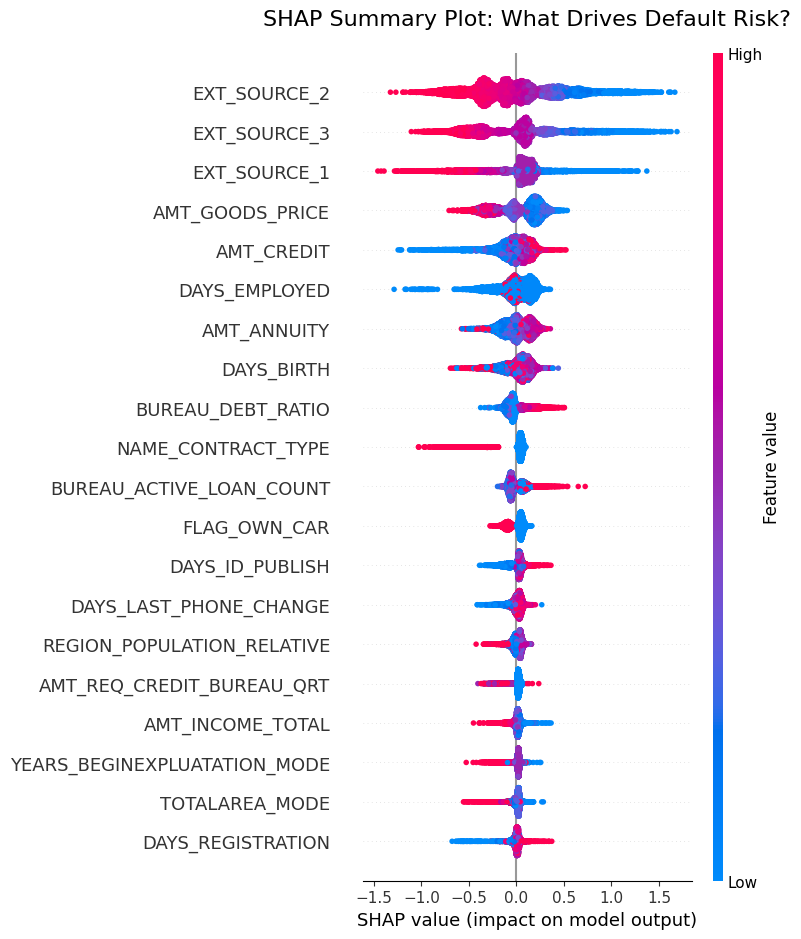

In [28]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model_v2)

X_shap_sample = X_test_v2.sample(n=10000, random_state=42)

shap_values = explainer.shap_values(X_shap_sample)

plt.figure(figsize=(10, 8))
plt.title('SHAP Summary Plot: What Drives Default Risk?', fontsize=16, pad=20)

if isinstance(shap_values, list):
    shap_data = shap_values[1]
else:
    shap_data = shap_values

shap.summary_plot(shap_data, X_shap_sample, show=False)

plt.tight_layout()
plt.show()

To ensure our model is transparent and complies with financial risk standards, we utilized SHAP (SHapley Additive exPlanations) to interpret how the LightGBM algorithm makes its decisions.

**How to Read This Chart:**

1. The Y-Axis (Top to Bottom): Features are ranked by importance. The feature at the very top has the biggest impact on the model's final decision.

2. The Color (Feature Value): Each dot represents a single person in the test set. Red means that person had a HIGH value for that feature (e.g., a large loan amount). Blue means they had a LOW value.

3. The X-Axis (Impact on Risk): Dots pushed to the Right (positive SHAP value) increase the risk of the customer defaulting. Dots pushed to the Left (negative SHAP value) decrease the risk.

**Key Business Insights:**

1. **The "Big Three" Dominate**: The model relies most heavily on EXT_SOURCE_2, 3, and 1 (normalized scores from external credit bureaus). The chart clearly shows that high external scores strongly push the prediction to the left, significantly lowering the risk of default. This aligns perfectly with standard banking logic: past reliable behavior is the best predictor of future reliability.

2. **The Loan-to-Goods Dynamic**: Features #4 (AMT_GOODS_PRICE) and #5 (AMT_CREDIT) show a fascinating financial relationship. A high requested loan amount (AMT_CREDIT) pushes the risk to the right. However, a high value for the actual goods being purchased (AMT_GOODS_PRICE) tends to lower the risk, suggesting that loans backed by high-value tangible assets are safer.

3. **Validation of Feature Engineering**: The custom-engineered feature, BUREAU_DEBT_RATIO, successfully broke into the top 10 most critical drivers. A high debt-to-credit ratio pushes the prediction to the right, increasing default risk. This proves that calculating the applicant's historical debt burden added massive, quantifiable predictive power to the model.

# Model Saving

In [29]:
import joblib

joblib.dump(model_v2, 'lgbm_best_model.pkl')

train_medians = X_train_v2.median().to_dict()
joblib.dump(train_medians, 'train_medians.pkl')

print("Model and Medians successfully exported!")

Model and Medians successfully exported!


#